# Wind Forecast Analysis

## Overview

This notebook focuses on analyzing the accuracy and reliability of wind power generation forecasts in the United Kingdom. The objective is twofold:

1. To evaluate how accurately the forecast model predicts wind generation across different forecast horizons  
2. To estimate how much wind power can be **reliably expected** to meet electricity demand  

Wind power is inherently variable and depends heavily on weather conditions. Therefore, both forecast accuracy and historical generation patterns must be analyzed to understand its practical contribution to the energy system.

---

## Dataset Description

Two datasets are used in this analysis:

### 1. Actual Generation (FUELHH)
- Source: BMRS API  
- Frequency: Half-hourly  
- Fields used:
  - `startTime`: Timestamp of generation  
  - `generation`: Actual wind power generation (MW)  

### 2. Forecasted Generation (WINDFOR)
- Source: BMRS API  
- Fields used:
  - `startTime`: Target time of generation  
  - `publishTime`: Time when forecast was issued  
  - `generation`: Forecasted wind power (MW)  

Only data from **January 2025 onwards** is considered, as specified in the assignment.

---

## Forecast Selection Logic

For each target time (`startTime`), the forecast used is:

> The latest forecast that was published at least *N hours* before the target time, where N is the Forecast Horizon.

This ensures that the evaluation reflects realistic operational conditions where forecasts are used ahead of time.

---

## Step 2: Forecast Analysis

The analysis is structured to understand the **error characteristics of the forecast model**:

- Forecast accuracy across multiple horizons (MAE, RMSE)
- Bias analysis (systematic over/under forecasting)
- Error distribution
- Time-of-day variation in forecast accuracy

---

## Reliability Analysis

In addition to forecast evaluation, historical wind generation is analyzed to determine:

> How much wind power can be reliably expected to meet electricity demand

This is done using lower percentile statistics (P10, P05), which provide a more realistic estimate of dependable capacity compared to averages.

---

In [76]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import timedelta

START = pd.Timestamp("2025-01-01", tz="UTC")
END = pd.Timestamp.now(tz="UTC").floor("30min")

print("Start:", START)
print("End  :", END)

Start: 2025-01-01 00:00:00+00:00
End  : 2026-03-18 11:00:00+00:00


In [24]:
FUELHH_URL = "https://data.elexon.co.uk/bmrs/api/v1/datasets/FUELHH/stream"
WINDFOR_URL = "https://data.elexon.co.uk/bmrs/api/v1/datasets/WINDFOR/stream"

In [ ]:
def bmrs_get(url, params):
    response = requests.get(url, params=params, timeout=120)
    response.raise_for_status()
    data = response.json()
    return data if isinstance(data, list) else data.get("data", [])

def fetch_fuelhh(start, end, fuel_type="WIND"):
    params = {
        "settlementDateFrom": start.date().isoformat(),
        "settlementDateTo": end.date().isoformat(),
        "fuelType": fuel_type,
    }
    
    data = bmrs_get(FUELHH_URL, params)
    df = pd.DataFrame(data)

    if df.empty:
        return df

    df["startTime"] = pd.to_datetime(df["startTime"], utc=True, errors="coerce")
    df["generation"] = pd.to_numeric(df["generation"], errors="coerce")

    df = df[(df["startTime"] >= start) & (df["startTime"] <= end)].copy()
    df = df[["startTime", "generation"]].rename(columns={"generation": "actual"})
    df = df.dropna(subset=["startTime", "actual"])
    df = df.sort_values("startTime")

    return df

def fetch_windfor(start, end, max_horizon_hours=48):
    publish_from = (start - timedelta(hours=max_horizon_hours)).normalize()

    params = {
        "publishDateTimeFrom": publish_from.isoformat(),
        "publishDateTimeTo": end.isoformat(),
    }

    data = bmrs_get(WINDFOR_URL, params)
    df = pd.DataFrame(data)

    if df.empty:
        return df

    df["startTime"] = pd.to_datetime(df["startTime"], utc=True, errors="coerce")
    df["publishTime"] = pd.to_datetime(df["publishTime"], utc=True, errors="coerce")
    df["generation"] = pd.to_numeric(df["generation"], errors="coerce")

    df = df[(df["startTime"] >= start) & (df["startTime"] <= end)].copy()

    df["horizon_hours"] = (
        (df["startTime"] - df["publishTime"]).dt.total_seconds() / 3600
    )

    df = df[(df["horizon_hours"] >= 0) & (df["horizon_hours"] <= max_horizon_hours)].copy()

    df = df[["startTime", "publishTime", "generation", "horizon_hours"]].rename(
        columns={"generation": "forecast"}
    )

    df = df.dropna(subset=["startTime", "publishTime", "forecast", "horizon_hours"])
    df = df.sort_values(["startTime", "publishTime"])
    return df



In [31]:
fuelhh = fetch_fuelhh(START, END, fuel_type="WIND")
fuelhh.head()

windfor = fetch_windfor(START, END, max_horizon_hours=48)
windfor.head()

,startTime,publishTime,forecast,horizon_hours
258836,2025-01-01 00:00:00+00:00,2024-12-30 02:30:00+00:00,16734,45.5
258763,2025-01-01 00:00:00+00:00,2024-12-30 04:30:00+00:00,17629,43.5
258690,2025-01-01 00:00:00+00:00,2024-12-30 07:30:00+00:00,18460,40.5
258617,2025-01-01 00:00:00+00:00,2024-12-30 09:30:00+00:00,18414,38.5
258544,2025-01-01 00:00:00+00:00,2024-12-30 11:30:00+00:00,18330,36.5


In [32]:
print("Actuals shape:", fuelhh.shape)
print("Actual range:", fuelhh["startTime"].min(), "→", fuelhh["startTime"].max())
fuelhh.describe()

print("Forecasts shape:", windfor.shape)
print("Forecast target range:", windfor["startTime"].min(), "→", windfor["startTime"].max())
print("Publish range:", windfor["publishTime"].min(), "→", windfor["publishTime"].max())

Actuals shape: (21187, 2)
Actual range: 2025-01-01 00:00:00+00:00 → 2026-03-18 09:00:00+00:00
Forecasts shape: (168547, 4)
Forecast target range: 2025-01-01 00:00:00+00:00 → 2026-03-18 09:00:00+00:00
Publish range: 2024-12-30 02:30:00+00:00 → 2026-03-18 07:30:00+00:00


In [ ]:
def process_data(fuel_df: pd.DataFrame, forecast_df: pd.DataFrame, horizon_hours: int):
    horizon_td = timedelta(hours=horizon_hours)

    fuel_df = fuel_df.copy()
    forecast_df = forecast_df.copy()

    # Convert timestamps
    fuel_df["startTime"] = pd.to_datetime(fuel_df["startTime"], utc=True, errors="coerce")
    forecast_df["startTime"] = pd.to_datetime(forecast_df["startTime"], utc=True, errors="coerce")
    forecast_df["publishTime"] = pd.to_datetime(forecast_df["publishTime"], utc=True, errors="coerce")

    # Standardize actual column
    if "generation" in fuel_df.columns and "actual" not in fuel_df.columns:
        fuel_df = fuel_df.rename(columns={"generation": "actual"})

    # Standardize forecast column
    if "generation" in forecast_df.columns and "forecast" not in forecast_df.columns:
        forecast_df = forecast_df.rename(columns={"generation": "forecast"})

    fuel_df["actual"] = pd.to_numeric(fuel_df["actual"], errors="coerce")
    forecast_df["forecast"] = pd.to_numeric(forecast_df["forecast"], errors="coerce")

    # Horizon filter
    forecast_df["horizonDiff"] = forecast_df["startTime"] - forecast_df["publishTime"]
    forecast_df = forecast_df[forecast_df["horizonDiff"] >= horizon_td].copy()

    # Sort so latest valid publishTime is last per startTime
    forecast_df = forecast_df.sort_values(["startTime", "publishTime"])

    # Pick latest forecast that is just below requested horizon
    forecast_selected = forecast_df.groupby("startTime", as_index=False).tail(1)

    actual_df = fuel_df[["startTime", "actual"]].copy()

    forecast_final_df = forecast_selected[
        ["startTime", "publishTime", "forecast", "horizonDiff"]
    ].copy()

    merged_df = pd.merge(
        actual_df,
        forecast_final_df,
        on="startTime",
        how="left"
    )

    merged_df = merged_df.sort_values("startTime").copy()
    merged_df = merged_df.dropna(subset=["forecast"]).copy()

    merged_df["selected_horizon_hours"] = (
        merged_df["horizonDiff"].dt.total_seconds() / 3600
    )

    merged_df["error"] = merged_df["forecast"] - merged_df["actual"]
    merged_df["abs_error"] = merged_df["error"].abs()
    merged_df["squared_error"] = merged_df["error"] ** 2

    merged_df = merged_df.replace([np.inf, -np.inf], np.nan)

    return merged_df

df_4h = process_data(fuelhh, windfor, horizon_hours=4)
df_4h.head()


,startTime,actual,publishTime,forecast,horizonDiff,selected_horizon_hours,error,abs_error,squared_error
0,2025-01-01 00:00:00+00:00,15799,2024-12-31 18:30:00+00:00,18601.0,0 days 05:30:00,5.5,2802.0,2802.0,7851204.0
2,2025-01-01 01:00:00+00:00,14992,2024-12-31 18:30:00+00:00,17803.0,0 days 06:30:00,6.5,2811.0,2811.0,7901721.0
4,2025-01-01 02:00:00+00:00,14685,2024-12-31 18:30:00+00:00,17504.0,0 days 07:30:00,7.5,2819.0,2819.0,7946761.0
6,2025-01-01 03:00:00+00:00,14831,2024-12-31 22:30:00+00:00,17926.0,0 days 04:30:00,4.5,3095.0,3095.0,9579025.0
8,2025-01-01 04:00:00+00:00,15078,2024-12-31 22:30:00+00:00,17669.0,0 days 05:30:00,5.5,2591.0,2591.0,6713281.0


Forecasts were evaluated at multiple horizons (1h, 12h, 24h, 36h) to understand how accuracy degrades over time. This aligns with real-world usage, where shorter horizons are operationally more reliable than longer-term forecasts.

In [56]:
df_1h = process_data(fuelhh, windfor, horizon_hours=1)
df_12h = process_data(fuelhh, windfor, horizon_hours=12)
df_24h = process_data(fuelhh, windfor, horizon_hours=24)
df_36h = process_data(fuelhh, windfor, horizon_hours=36)

In [57]:
def summarize_errors(df, horizon):
    return pd.Series({
        "n": len(df),
        "mean_error": df["error"].mean(),
        "mae": df["abs_error"].mean(),
        "rmse": np.sqrt(df["squared_error"].mean()),
        "median_ae": df["abs_error"].median(),
        "p90_ae": df["abs_error"].quantile(0.90),
        "p95_ae": df["abs_error"].quantile(0.95),
        "p99_ae": df["abs_error"].quantile(0.99),
        "horizon_hours": horizon,
    })

summary = pd.DataFrame({
    "1h": summarize_errors(df_1h, 1),
    "4h": summarize_errors(df_4h, 4),
    "12h": summarize_errors(df_12h, 12),
    "24h": summarize_errors(df_24h, 24),
    "36h": summarize_errors(df_36h, 36),
}).T

summary

,n,mean_error,mae,rmse,median_ae,p90_ae,p95_ae,p99_ae,horizon_hours
1h,10594.0,1252.641778,1467.211912,1996.352886,1029.0,3450.4,4244.35,5831.05,1.0
4h,10594.0,1292.570700,1506.334718,2026.126121,1088.0,3498.0,4262.00,5822.98,4.0
12h,10594.0,1325.292146,1589.518123,2087.659904,1210.5,3529.4,4305.35,5846.75,12.0
24h,10594.0,1358.848310,1687.792618,2189.321910,1324.0,3714.0,4432.00,5834.28,24.0
36h,10594.0,1384.621673,1816.149141,2319.572118,1457.0,3873.0,4671.00,6023.07,36.0


# Forecast Accuracy vs Horizon
## Analysis

The forecast accuracy was evaluated across multiple forecast horizons using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).
MAE increases steadily as forecast horizon increases
RMSE increases at a faster rate than MAE

## Interpretation

The increase in error with horizon is expected, as longer-horizon forecasts rely on less recent weather information.
The faster growth in RMSE compared to MAE indicates the presence of occasional large forecast errors (outliers).
The smooth increase suggests that the model degrades consistently rather than erratically.

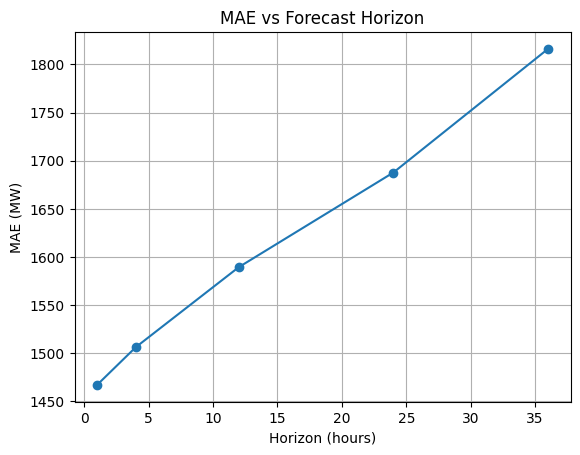

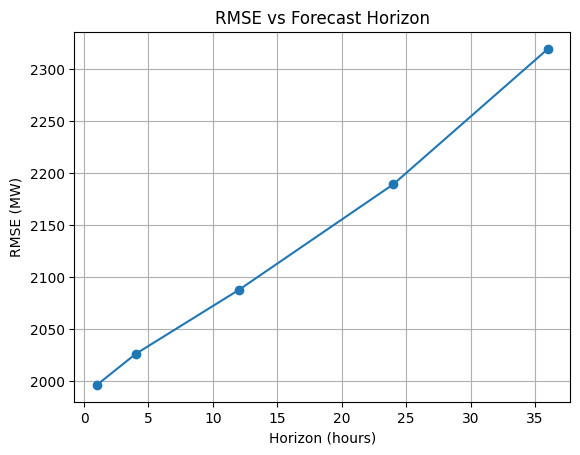

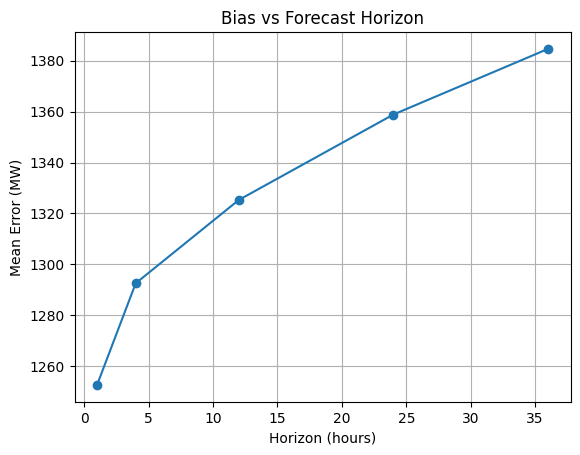

In [79]:
plt.plot(summary["horizon_hours"], summary["mae"], marker="o")
plt.title("MAE vs Forecast Horizon")
plt.xlabel("Horizon (hours)")
plt.ylabel("MAE (MW)")
plt.grid()
plt.show()

plt.plot(summary["horizon_hours"], summary["rmse"], marker="o")
plt.title("RMSE vs Forecast Horizon")
plt.xlabel("Horizon (hours)")
plt.ylabel("RMSE (MW)")
plt.grid()
plt.show()

plt.plot(summary["horizon_hours"], summary["mean_error"], marker="o")
plt.title("Bias vs Forecast Horizon")
plt.xlabel("Horizon (hours)")
plt.ylabel("Mean Error (MW)")
plt.grid()
plt.show()

In [60]:
df = df_4h.copy()

df["hour"] = df["startTime"].dt.hour
df["day_of_week"] = df["startTime"].dt.dayofweek
df["month"] = df["startTime"].dt.month

# 4. Time-of-Day Error Analysis

## Analysis

- Below, Forecast errors were analyzed by hour of day.MAE varies significantly across hours,
- Highest errors occur during early hours (00:00–06:00 UTC)
- Lowest errors occur during midday (12:00–15:00 UTC)

## Interpretation

- Forecast accuracy exhibits a clear diurnal pattern
- Higher errors during early hours suggest increased uncertainty or variability in overnight wind conditions
- Lower errors during midday indicate more stable or predictable conditions
- This suggests that forecast performance is influenced by underlying meteorological dynamics

In [61]:
hourly_summary = df.groupby("hour").apply(summarize_errors, horizon=4).reset_index()

hourly_summary

,hour,n,mean_error,mae,rmse,median_ae,p90_ae,p95_ae,p99_ae,horizon_hours
0,0,442.0,1503.027149,1689.638009,2199.329726,1261.5,3834.0,4709.05,5612.08,4.0
1,1,442.0,1510.855204,1710.714932,2237.998250,1313.5,3824.1,4743.40,5878.67,4.0
2,2,442.0,1513.807692,1725.640271,2240.119686,1330.5,3837.8,4551.90,5757.42,4.0
3,3,442.0,1506.585973,1715.097285,2267.170210,1341.5,3978.7,4781.95,6079.30,4.0
4,4,442.0,1573.880090,1736.287330,2295.729253,1247.0,3905.0,4817.40,6313.86,4.0
5,5,442.0,1577.753394,1727.174208,2287.383306,1354.5,3819.1,4792.00,6606.61,4.0
6,6,442.0,1539.667421,1704.843891,2248.938771,1269.5,3797.0,4353.00,6468.02,4.0
7,7,442.0,1417.312217,1581.954751,2094.720916,1128.5,3599.1,4160.15,5838.76,4.0
8,8,442.0,1307.260181,1453.554299,1972.372291,1034.0,3310.8,4029.45,5506.73,4.0
9,9,442.0,1247.047511,1411.911765,1935.507686,1006.0,3308.7,4058.80,5824.02,4.0


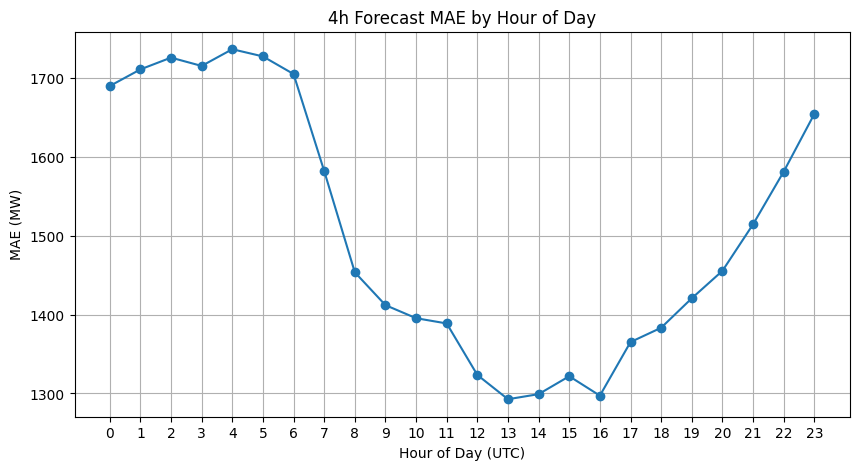

In [62]:
plt.figure(figsize=(10, 5))
plt.plot(hourly_summary["hour"], hourly_summary["mae"], marker="o")
plt.title("4h Forecast MAE by Hour of Day")
plt.xlabel("Hour of Day (UTC)")
plt.ylabel("MAE (MW)")
plt.xticks(range(24))
plt.grid()
plt.show()

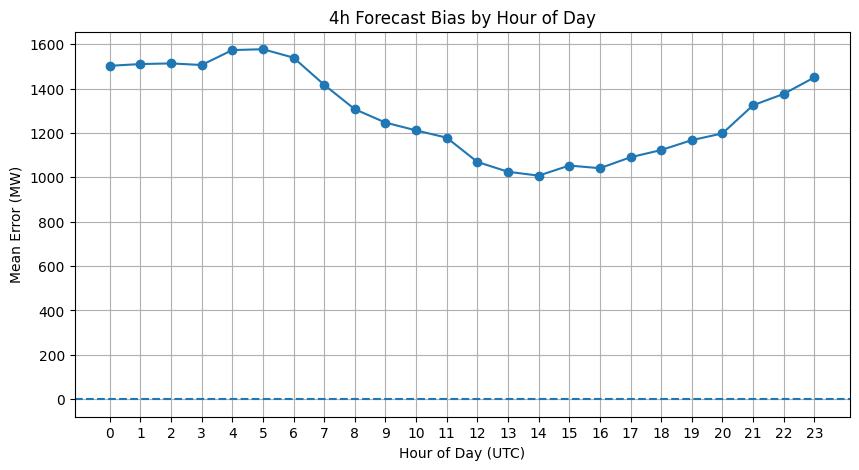

In [63]:
plt.figure(figsize=(10, 5))
plt.plot(hourly_summary["hour"], hourly_summary["mean_error"], marker="o")
plt.axhline(0, linestyle="--")
plt.title("4h Forecast Bias by Hour of Day")
plt.xlabel("Hour of Day (UTC)")
plt.ylabel("Mean Error (MW)")
plt.xticks(range(24))
plt.grid()
plt.show()

# Distribution of Wind Generation

## Analysis

- The distribution of actual wind generation was analyzed across the entire dataset.

## Interpretation

- Wind generation exhibits a wide distribution, indicating high variability
- The mean (~8000MW ) is significantly higher than lower percentile values
- This confirms that average generation is not a reliable indicator of available capacity

In [64]:
actual_summary = pd.Series({
    "mean_mw": fuelhh["actual"].mean(),
    "median_mw": fuelhh["actual"].median(),
    "p05_mw": fuelhh["actual"].quantile(0.05),
    "p10_mw": fuelhh["actual"].quantile(0.10),
    "p25_mw": fuelhh["actual"].quantile(0.25),
    "p50_mw": fuelhh["actual"].quantile(0.50),
    "p75_mw": fuelhh["actual"].quantile(0.75),
    "p90_mw": fuelhh["actual"].quantile(0.90),
})

actual_summary

mean_mw       8417.46217
median_mw     8015.00000
p05_mw        1885.00000
p10_mw        2634.00000
p25_mw        4618.50000
p50_mw        8015.00000
p75_mw       12175.00000
p90_mw       14913.40000
dtype: float64

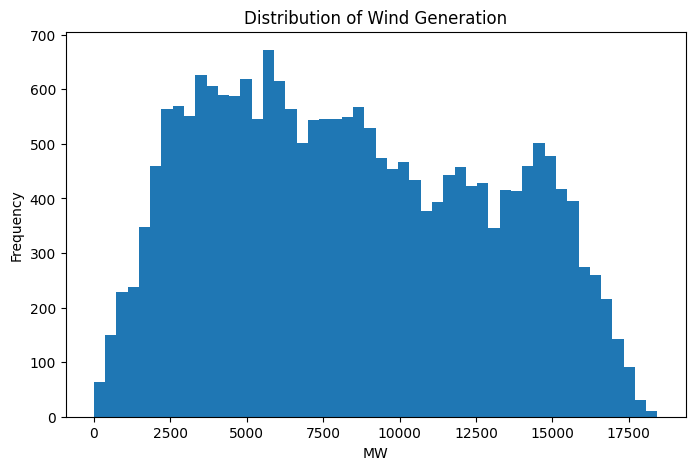

In [65]:
plt.figure(figsize=(8, 5))
plt.hist(fuelhh["actual"], bins=50)
plt.title("Distribution of Wind Generation")
plt.xlabel("MW")
plt.ylabel("Frequency")
plt.show()

# Monthly Wind Reliability
## Analysis

- Wind generation was analyzed on a monthly basis using lower percentiles (P05, P10).
- P10 represents generation available 90% of the time
- P05 represents generation available 95% of the time

## Interpretation

- Wind generation shows strong seasonal variation
- Winter months (Nov–Feb) have higher reliable output (~5000–6500 MW)
- Summer months (Apr–Aug) have significantly lower reliable output (~1500–2500 MW)
- There is a large gap between mean and P10 values in all months, indicating variability

In [74]:
fuelhh["month"] = fuelhh["startTime"].dt.month
monthly_summary = fuelhh.groupby("month")["actual"].agg([
    "mean",
    "median",
    lambda x: x.quantile(0.05),
    lambda x: x.quantile(0.10),
])

monthly_summary.columns = ["mean", "median", "p05", "p10"]
monthly_summary


,mean,median,p05,p10
month,,,,
1,9884.557460,10138.0,2342.00,2988.5
2,10439.268601,10345.0,4207.85,5096.4
3,8190.987086,7252.0,2112.90,2799.6
4,5392.703472,4591.0,1263.75,1633.0
5,6275.985887,5530.0,2194.05,2532.1
6,7511.895139,6976.5,1721.05,3184.1
7,4460.528226,3808.0,986.85,1564.5
8,5978.409274,5570.5,1128.35,1673.5
9,8843.104167,7995.0,2822.80,3709.6


## Reliable Wind Generation Capacity

To estimate how much wind generation can be **reliably expected** to meet demand, I focused on the **10th percentile (P10)** of historical actual generation.

### Why use P10?

For a given month, the P10 value means that wind generation is at least that level in **90% of time intervals** during that month. This makes it a useful measure of **dependable lower-bound availability** (like in July), as opposed to the mean or median, which can overstate what is actually reliable.

### Why not use the mean?

Monthly mean wind generation ranges from roughly **4.5 GW to 11.1 GW**, but these averages are not dependable planning values because wind output is highly variable. For example:

- July mean generation is **4461 MW**
- July P10 is only **1565 MW**

This large gap shows that average generation is much higher than what can be relied upon most of the time.

### Seasonal variation matters

The monthly P10 values vary significantly:

- Stronger months:  
  - February: **5096 MW**
  - November: **5225 MW**
  - December: **6504 MW**

- Weaker months:  
  - April: **1633 MW**
  - July: **1565 MW**
  - August: **1674 MW**
  - October: **1793 MW**

This means a single year-round “reliable” value must be based on the **weakest months**, not the stronger ones.

### Final recommendation

I recommend using **1600 MW** as the year-round reliable wind generation estimate.

### Reasoning

- The lowest monthly P10 is **1564.5 MW** (July)
- This represents a level of wind generation that is available in **about 90% of intervals even in the weakest month**